# Bias Analysis on H-R Diagram with Gaia DR3 data (I)

```Authors: Paul Alvarez updated: 20260722```


These notebooks present a study on bias in parallax-based distance estimation. By constructing a Hertzsprung-Russell diagram, the study analyze the impact of Lutz-Kelker bias on stellar distance estimates and explores methods to adress its effects; investigate the probabilistic inference problem proposed by Bailer-Jones for estimating stellar distances and investigates how interstellar extinction influences the calculation and visualization of the corrected Hertzsprung–Russell diagram.

This first notebook focuses on retrieving stellar data from Gaia DR3 (via Astroquery) for a selected region of the sky (e.g., the Pleiades) and analyzes the limitations of estimating stellar distances thought parallax inversion, examines the origin and impact.

## Table of contents:
* [Required libraries](#Required-libraries)
* [Introduction](#Introduction)
* [Dataset](#Dataset)
* [Initial Approuch](#initial-naive-approuch)
* [Lutz-Kelker Bias](#lutz-kelker-bias)


## Required libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from astroquery.gaia import Gaia
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

## Introduction 

The Hertzsprung-Russell diagram (HR diagram) is one of the most important tools in the study of stellar evolution. Developed independently in the early 1900s by Ejnar Hertzsprung and Henry Norris Russell, it plots the temperature of stars against their luminosity (the theoretical HR diagram), or the colour of stars (or spectral type) against their absolute magnitude (the observational HR diagram, also known as a colour-magnitude diagram, which we refers in this study).

Depending on its initial mass, every star goes through specific evolutionary stages dictated by its internal structure and how it produces energy. Each of these stages corresponds to a change in the temperature and luminosity of the star, which can be seen to move to different regions on the HR diagram as it evolves. This reveals the true power of the HR diagram – astronomers can know a star’s internal structure and evolutionary stage simply by determining its position in the diagram (COSMOS, Swinburne University of Technology).

However, the utility of the observational H-R diagram in understanding stellar formation and structure relies primarily on the assumption that the magnitude is unbiased (or, at least, not significantly so). In this context, a reliable distance is required to calculate the magnitude; otherwise, additional biases are introduced into the measurement process. This gives rise to the primary motivation for this study: to examine the widely used "naive" distance estimator, 1/ϖ, and its impact on absolute magnitude calculations and the resulting HR diagram, as well as to analyze and implement corrections for the associated biases, such as Bayesian distance estimates. In particular, we explore the construction of the Hertzsprung–Russell (H-R) diagram using Gaia DR3 data for the Pleiades star cluster in order to investigate the effects and limitations of estimating stellar distances from the inverse of the measured parallax, 


## Dataset

To define the region of the GAIA data to be examined, we will use the celestial location of the Pleiades (M45) as a guide. Since it is a star cluster, we know that the stars formed at the same time and are all at the same distance from us, which results in less noise than other regions when using the stellar data for an HR diagram. It is also worth noting that we will not initially use reliability parameters (such as the commonly used RUWE (Renormalized Unit Weight Error) as a filter) in the queries; doing so would restrict the sample to stars with reliable and accurate measurements, thereby preventing us from assessing the impact of poor parallax measurements.

In [2]:
# Save data
DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# Pleiades open cluster
ra_target = 56.75   
dec_target = 24.12 
radius_deg = 1

# Metadata for the study
query = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_error, 
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag,
    ruwe,
    visibility_periods_used,
    astrometric_excess_noise,
    parallax_over_error
FROM gaiadr3.gaia_source
WHERE
    CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra_target}, {dec_target}, {radius_deg})
    ) = 1
    AND parallax > 0
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
"""

# Get the query results
job = Gaia.launch_job_async(query)
results_table = job.get_results()

# Convert table to dataframe
df_gaia = results_table.to_pandas()
print(f"Size of the sample: {len(df_gaia)} stars collected.")

INFO: Query finished. [astroquery.utils.tap.core]
Size of the sample: 19966 stars collected.


In [12]:
print("First records from the sample:")
print(df_gaia[['source_id', 'parallax', 'parallax_error', 'ruwe', 'phot_g_mean_mag']].head())

print("\nDescriptive statistics for the resulting sample:")
print(df_gaia[['parallax', 'parallax_error', 'ruwe']].describe())

First records from the sample:
           source_id  parallax  parallax_error      ruwe  phot_g_mean_mag
0  64878779542180096  0.874177        0.649277  0.983892        20.001284
1  64879535456420480  1.587769        0.353551  1.012434        19.050779
2  64879574111509760  0.880168        0.112466  1.111856        17.296883
3  64879707255111808  0.643300        0.176350  1.006028        18.153240
4  64906271629189888  0.388585        0.169606  0.927529        17.780079

Descriptive statistics for the resulting sample:
           parallax  parallax_error          ruwe
count  19966.000000    19966.000000  19966.000000
mean       1.163068        0.376157      1.097889
std        1.528277        0.407700      0.731691
min        0.000131        0.013005      0.751886
25%        0.357661        0.093014      0.982287
50%        0.708272        0.229894      1.019763
75%        1.332549        0.514376      1.062425
max       41.460972        3.794487     38.557499


Even among the first stars in the sample, we can observe considerable variation in the parallax error (ranging from $\pm 0.112$ to $\pm 0.649$ in terms of $\sigma_\varpi$ deviations), which suggests, at first glance, that parallax precision is not uniform.

Now, analyzing the descriptive summary statistics, we observe that despite a mean parallax of $\approx 1.163$ mas, the median value is $\approx 0.708$ mas; the parallax distribution is skewed toward lower values. Furthermore, the mean parallax measurement error is $\approx 0.376$ mas, with a standard deviation of $\approx 0.407$ mas, indicating considerable dispersion in measurement precision. In addition, although the sample was not filtered based on astrometric reliability parameters, the median RUWE is $\approx 1.019$, with a 75th percentile of $\approx 1.062$; since both values ​​are close to 1, the overall astrometric fit is good, despite the presence of measurements with extremely high RUWE values (such as $\approx 38.556$) which may indicate measurement errors or outlier objects (e.g., unresolved binaries or extended sources like galaxies or nebulae).

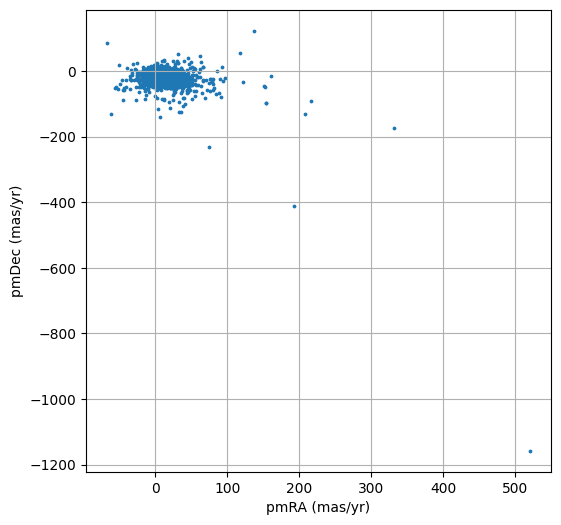

In [ ]:
# Examine the pleiades open cluster
plt.figure(figsize=(6,6))
plt.scatter(df_gaia["pmra"], df_gaia["pmdec"], s=3)
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.grid(True)

In [29]:
# Redefine the cluster
df_gaia = df_gaia[
    (df_gaia["pmra"] > -70) &
    (df_gaia["pmra"] < 90) &
    (df_gaia["pmdec"] > -80) &
    (df_gaia["pmdec"] < 40)
]

## Initial approuch

It is important to note that any bias in the measured parallax propagates directly into the derived absolute magnitudes through the absolute magnitude relation

$$
M_G = m_G - 5 \log_{10}(d(pc)) + 5,
$$

where $m_G$ is the apparent magnitude and $d(pc)$ is the true distance to a star in parsecs. Then, using the estimate based on parallax, we have:

$$
M_G = m_G - 5 \log_{10}\left(\frac{1}{\mathrm{parallax}}\right) + 5
$$



Gaia does not measure parallax in arcseconds but rather in milliarcseconds (mas); therefore, the estimate used for the distance (in parsecs) is given by:


$$
d(pc) = \frac{1000}{p(mas)}
$$


Therefore, in this initial (naive) approach, we will use the distance-parallax relation to compute the magnitude of each star in our sample and construct the resulting Hertzsprung-Russell diagram for the previously selected Pleiades star cluster.

In [30]:
# Save figures
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

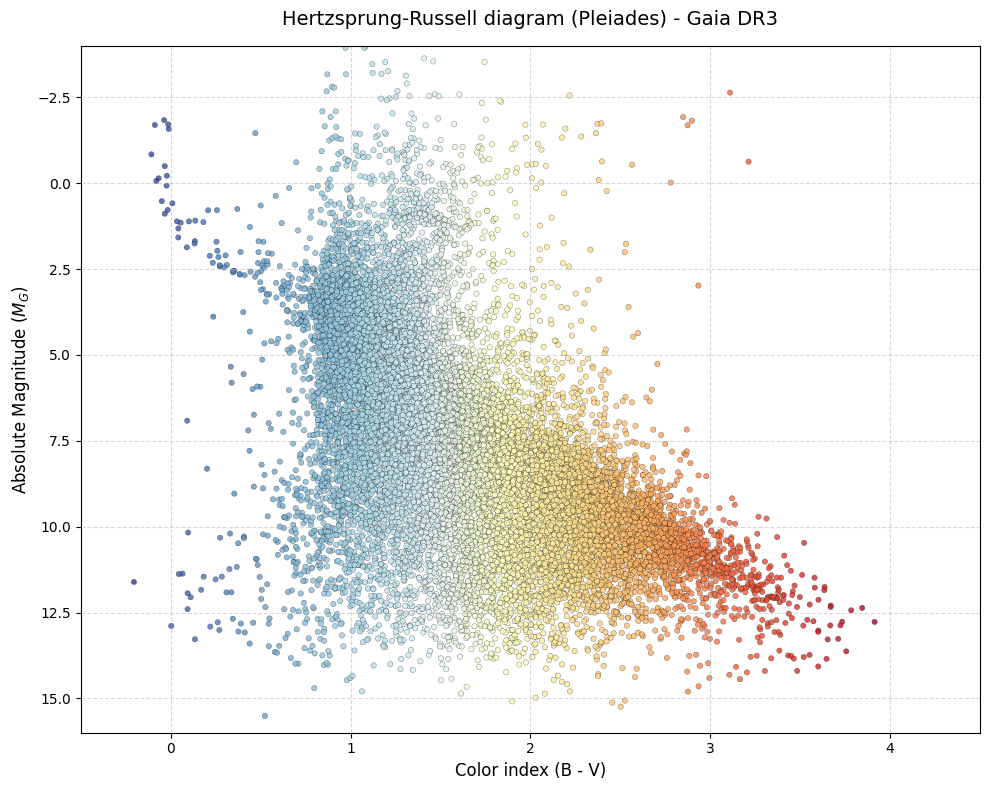

In [31]:
# Calculate the absolute g using the naive approach
pc_distance = 1000.0 / df_gaia['parallax'] # Gaia used 'mas' instead of pc
df_gaia['absolute_g'] = df_gaia['phot_g_mean_mag'] - 5.0 * np.log10(pc_distance) + 5.0 # Absolute and observational magnitude relation

# Color idx: BP - RP
df_gaia['bp_rp'] = df_gaia['phot_bp_mean_mag'] - df_gaia['phot_rp_mean_mag']

# HR diagrama
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_gaia['bp_rp'], df_gaia['absolute_g'], c=df_gaia['bp_rp'], cmap='RdYlBu_r', 
                s=15, edgecolor='black', linewidths=0.2, alpha=0.8)

plt.gca().invert_yaxis()
plt.title('Hertzsprung-Russell diagram (Pleiades) - Gaia DR3', fontsize=14, pad=15)
plt.xlabel('Color index (B - V)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.5, 4.5)
plt.ylim(16, -4) 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "hr_diagram_biased.png"), dpi=300, bbox_inches="tight")
plt.show()


We can observe that, although the H-R diagram displays the expected overall morphology (namely, the most luminous stars are located at the top of the diagram, and stars with high surface temperatures are on the left side), the plot exhibits significant scatter and noise. Specifically, we can see a grouping of stars in the lower-left quadrant (sources with high absolute magnitude and a lower color index).


To investigate this behaviour, let us first denote the parallax fractional error, which is computed directly from the sample measurement as $f = \frac{\sigma_{\varpi}}{\varpi}$ (Bailer-Jones, 2015). Taking its reciprocal yields the signal-to-noise ratio of the parallax measurement:

$$
f = \frac{\sigma_{\varpi}}{\varpi} = \frac{1}{\mathrm{SNR}},
\qquad
\mathrm{SNR} = \frac{\varpi}{\sigma_{\varpi}}.
$$

Now, according to the analyses by Lutz and Kelker (1973) and Bailer-Jones (2015), the parallax measurement error becomes unstable as a distance estimator when $f > 0.2$, which translates to a permissible signal-to-noise ratio of $\mathrm{SNR} > 5$.

In [32]:
df_gaia["snr"] = (df_gaia["parallax"] / df_gaia["parallax_error"])
highly_biased_measures = (df_gaia["snr"] <= 5).mean() 
print(f"Percentage of distances which are highly biased: {highly_biased_measures * 100}%")

Percentage of distances which are highly biased: 66.44581639311349%


Most stars in the sample are significantly biased in their parallax measurements; consequently, the associated calculated metrics (e.g., absolute magnitude) are also biased. At first glance, this may explains the general scatter and noise in the previous H-R diagram. However, this does not explain the earlier observated concentration of stars in the lower-left region of the Hertzsprung-Russell diagram. To investigate this feature, we first analyze the distribution of highly biased stars ($\mathrm{SNR} \leq 5$) across different regions of the diagram.

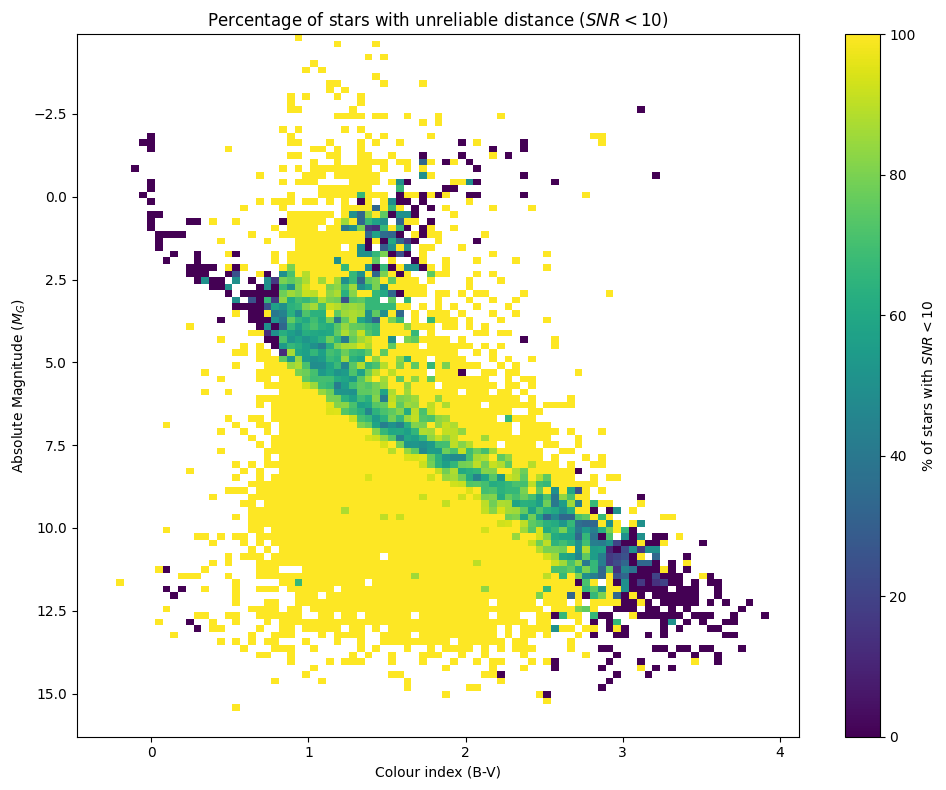

In [33]:
# Stars with unreliable distance
df_gaia["bad_distance"] = df_gaia["snr"] < 10

color_bins = np.arange(-0.5, 4.2, 0.05)
mag_bins = np.arange(-5, 16.5, 0.2)
df_gaia["color_bin"] = pd.cut(df_gaia["bp_rp"], color_bins)
df_gaia["mag_bin"] = pd.cut(df_gaia["absolute_g"], mag_bins)

# Percentage of stars with unreliable distance 
heat = (df_gaia.groupby(["mag_bin", "color_bin"], observed=False)["bad_distance"].mean().unstack()* 100)

# Define the axes for coloring each one
x = [i.mid for i in heat.columns] 
y = [i.mid for i in heat.index]

# Plot the HR diagram color by % of stars with SNR < 10 in the corresponding region 
plt.figure(figsize=(10,8))
im = plt.imshow(heat, origin="lower", aspect="auto", extent=[x[0], x[-1], y[0], y[-1]], cmap="viridis", vmin=0, vmax=100)
plt.gca().invert_yaxis()
plt.xlabel(r"Colour index (B-V)")
plt.ylabel(r"Absolute Magnitude ($M_G$)")
plt.title("Percentage of stars with unreliable distance ($SNR<10$)")
cbar = plt.colorbar(im)
cbar.set_label("% of stars with $SNR<10$")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "hr_diagram_snr_per_region_biased.png"), dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# Save current data
save_path = os.path.join(DATA_DIR, "df_gaia_processed.csv")
df_gaia.to_csv(save_path, index=False)

## Lutz-Kelker bias

Trumpler and Weaver (1953) discuss a systematic error which they attribute to the process of selecting stars by a lower limit in parallax values. Because parallax measurements are subject to observational errors, some stars that are actually outside this limit (i.e., more distant) will be overestimated and included in the sample. At the same time, some stars that should be inside (i.e., closer) will be underestimated and excluded. Lutz and Kelker (1973) extended this analysis and proposed that the bias introduced by parallax measurement is not limitated to samples selectec using a lower parallax limit. Instead, they demostrated that it affects all parallax values ​​and is a consequence not only of observational errors but also from the underlying spatial distribution of stars.


The Lutz-Kelker bias refers to a geometric effect arising from the simple fact that stars are distributed in three-dimensional space rather than along a straight line. When a measurement (e.g., parallax) is obtained, it carries an associated error assumed to be symmetrically (Gaussian) distributed around the true parallax value. Consequently, one might expect the probability of a star's parallax being overestimated (making it appear closer) to equal the probability of it being underestimated (making the star appear more distant). However, since stars are distributed in three-dimensional space rather than in a one-dimensional space (i.e., a straight line), the volume of stars increases with the square of the distance ($r^{2}$) (Lutz and Kelker, 1973):

The Lutz-Kelker bias refers to a geometric effect that arises because stars are distributed in three-dimensional space. When a quantity such as the parallax is measured, the measurement is subject to observational errors; assumed to be distributed symmetrically (Gaussian) about the true parallax. Under this assumption, one might expect the probability of overstimating a star's parallax (making it appear closer) to be equal to the probability of underestimating it (making the star appear more distant). However, since stars are distributed in three-dimensional rather than along a one-dimensional line, and assuming uniform spatial density, the volume (number) of stars increases with the square of the distance ($r^{2}$).


$$dV = 4\pi r^2 dr$$

This results in a much larger number of distant stars than nearby ones. Consequently, there are more distant stars whose parallaxes are overstimated than nearby stars whose parallaxes are understimated. As a result, when distances are estimated by simply inverting the measured parallax, we will inherently, on average, overestimate parallaxes and underestimate distances, thereby calculating higher absolute magnitudes, since on:

$$
M_G = m_G - 5 \log_{10}(d(pc)) + 5,
$$


the function $\log_{10}(d(pc))$ is a monotonically increasing function of distance, and given that $d(pc) > 0$, the systematic underestimation of distances caused by the Lutz–Kelker bias leads to larger values of $M_G$. As a result, stars appear intrinsically fainter than they actually truly are.




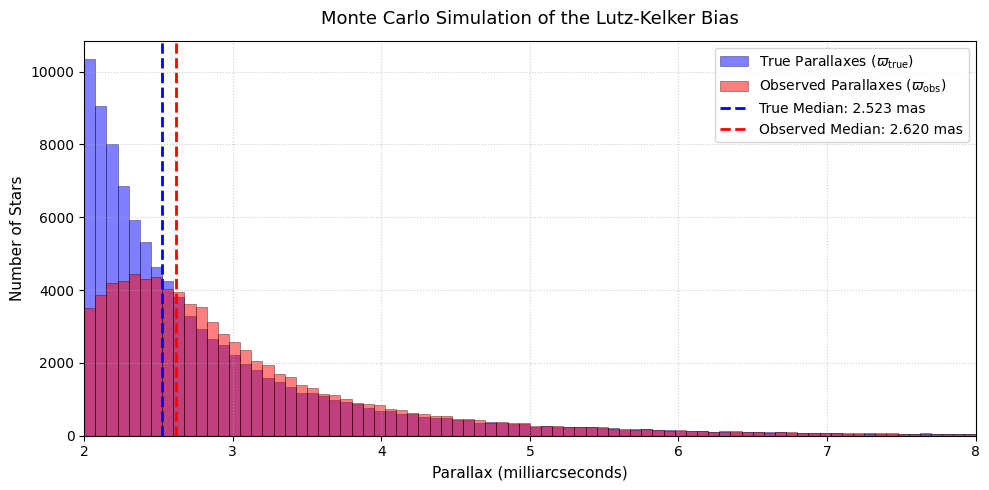

In [35]:
np.random.seed(666)

'''
We developed a Monte Carlo simulation to model the spatial distribution of stars by introducing noise into the
simulated parallax measurements. This allowed us to examine and observe the underlying  distance distribution 
and to compare the true distances with those estimated from the observed parallaxes.
'''

# For a constant spatial density (uniform), the distance r follows a distribution proportional to r^2
N_stars = 100000
r_max = 500  # Maximum distance in parsecs
true_distances = r_max * (np.random.uniform(0, 1, N_stars))**(1/3)
true_parallaxes = 1000.0 / true_distances

# Introduce observational errors (Gaussian type)
parallax_sigma = 0.4 # 0.4 mas uncertainty (based in the Gaia sample)
errors = np.random.normal(0, parallax_sigma, N_stars)
observed_parallaxes = true_parallaxes + errors

# Apply a selection criterion (based on S/N > 5 in the Gaia sample) (realible star measurements)
#mask = (observed_parallaxes / parallax_sigma) > 5.0
true_parallaxes_filtered = true_parallaxes
observed_parallaxes_filtered = observed_parallaxes

# Plot the distributions to illustrate the bias
plt.figure(figsize=(10, 5))

# Histogram of true versus observed parallaxes
plt.hist(true_parallaxes_filtered, bins=80, range=(2, 8), alpha=0.5, 
    label='True Parallaxes ($\\varpi_{\\mathrm{true}}$)', color='blue',
    edgecolor='black', linewidth=0.5
)

plt.hist(observed_parallaxes_filtered, bins=80, range=(2, 8), alpha=0.5, 
    label='Observed Parallaxes ($\\varpi_{\\mathrm{obs}}$)', color='red',
    edgecolor='black', linewidth=0.5
)

# Compute and display the medians to quantify the bias
true_median = np.median(true_parallaxes_filtered)
observed_median = np.median(observed_parallaxes_filtered)
plt.axvline(true_median, color='blue', linestyle='dashed', linewidth=2, label=f'True Median: {true_median:.3f} mas')
plt.axvline(observed_median, color='red', linestyle='dashed', linewidth=2, label=f'Observed Median: {observed_median:.3f} mas')

plt.title('Monte Carlo Simulation of the Lutz-Kelker Bias', fontsize=13, pad=12)
plt.xlabel('Parallax (milliarcseconds)', fontsize=11)
plt.ylabel('Number of Stars', fontsize=11)
plt.xlim(2, 8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "mc_sim_lutz-kelker_bias.png"), dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# Numerical summary of the bias
print(f"Median TRUE Parallax: {true_median:.3f} mas : TRUE Distance: {1000 / true_median:.1f} pc")
print(f"Median OBSERVED Parallax: {observed_median:.3f} mas : NAIVE Distance (1/ϖ): {1000 / observed_median:.1f} pc")
print(f"BIAS: The observed parallaxes are shifted to the right by {observed_median - true_median:.3f} mas.")

Median TRUE Parallax: 2.523 mas : TRUE Distance: 396.4 pc
Median OBSERVED Parallax: 2.620 mas : NAIVE Distance (1/ϖ): 381.7 pc
BIAS: The observed parallaxes are shifted to the right by 0.097 mas.


We find a definite systematic bias toward parallax overestimation after executing the Monte Carlo simulation and looking at the histogram comparison between the true and measured parallaxes. The median true parallax is $\approx 2.523$ mas, corresponding to a true distance of $\approx 396.4$ pc. In contrast, the median measured parallax is 2.620 mas (representing a rightward shift of $\approx 0.1$ mas), which results in a inferred distance of $\approx 381.7$ pc. These results quantitatively illustrate the Lutz–Kelker bias, whereby parallaxes are systematically overestimated and distances consequently underestimated.


Nevertheless, the limitations of the Monte Carlo simulation should be acknowledged; in this simplified model, we are introducing a constant bias of $+0.4\sigma$ on every parallax measurement. However, in reality, measurements error vary from star to star, and larger uncertainties may potentially lead to substantially larger shifts in the observer parallax distribution for stars with high $\sigma$ values.



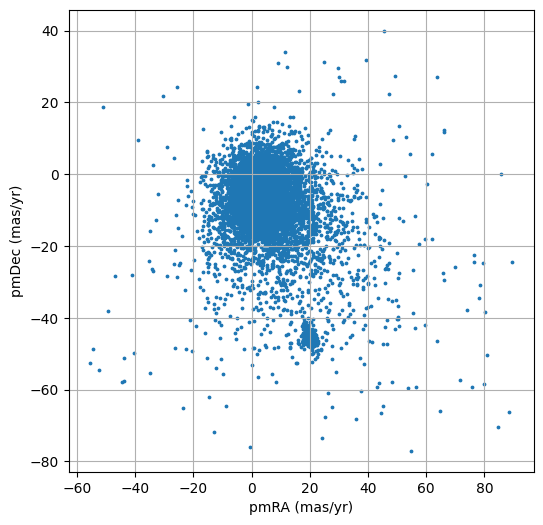

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(df_gaia["pmra"], df_gaia["pmdec"], s=3)
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.grid(True)

In [38]:
X = df_gaia[["pmra", "pmdec", "parallax"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
db = DBSCAN(
    eps=0.25,
    min_samples=20
)

labels = db.fit_predict(X_scaled)
df_gaia["cluster"] = labels

Text(0, 0.5, 'pmDec')

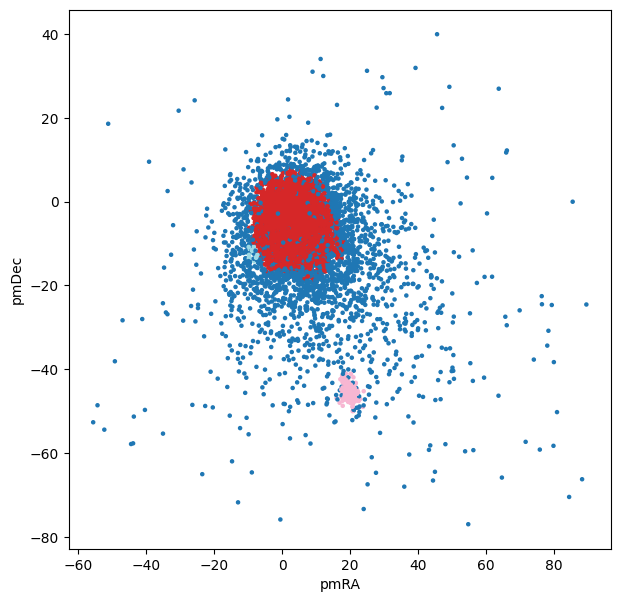

In [40]:
plt.figure(figsize=(7,7))

plt.scatter(
    df_gaia["pmra"],
    df_gaia["pmdec"],
    c=df_gaia["cluster"],
    s=5,
    cmap="tab20"
)

plt.xlabel("pmRA")
plt.ylabel("pmDec")